<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Global_Alcohol_Consumption_(WHO%2C_2000%E2%80%932022)_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Alcohol Consumption (WHO, 2000–2022)


# About the dataset and insights

This dataset provides a comprehensive overview of global alcohol consumption per capita for the years 2000 to 2022, as compiled by the World Health Organization (WHO). It's a clean and well-structured dataset, evident from the absence of any missing values or duplicates across its 4324 entries.

Each entry in the dataset represents a specific country's alcohol consumption in a given year, measured in liters of pure alcohol per capita (alcohol_liters_per_capita). Importantly, the consumption figures are aggregated for 'Both sexes', meaning the data does not offer a breakdown by gender. This implies that any analysis or insights derived will reflect overall population consumption rather than gender-specific patterns.

Beyond the raw consumption figures, the dataset includes confidence intervals (lower_ci, upper_ci) and their width (ci_width). These are crucial for understanding the statistical reliability and precision of the alcohol consumption estimates. A wider confidence interval suggests greater uncertainty in the estimate, which can be an important consideration when comparing consumption rates across different countries or years.

The presence of country and iso3 codes enables robust geographical analysis, allowing us to identify nations with higher or lower consumption rates and potentially explore regional trends. The year column, spanning over two decades, is vital for temporal analysis, helping to uncover how alcohol consumption patterns have evolved globally over time.

While the IndicatorCode column is present, it contains a single unique value, indicating it's likely a fixed identifier for this specific type of data collection rather than a variable for deeper analysis. Overall, this dataset is a valuable resource for studying global alcohol consumption trends, geographical variations, and the confidence associated with these public health metrics.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ibrahimqasimi/global-alcohol-consumption-who-20002022

# Unziping the downloaded file
!unzip global-alcohol-consumption-who-20002022.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/ibrahimqasimi/global-alcohol-consumption-who-20002022
License(s): apache-2.0
  0% 0.00/138k [00:00<?, ?B/s]
100% 138k/138k [00:00<00:00, 360MB/s]
Archive:  global-alcohol-consumption-who-20002022.zip
  inflating: who_alcohol_total_per_capita_2000_2022_clean.csv  


In [33]:
df = pd.read_csv('who_alcohol_total_per_capita_2000_2022_clean.csv')
df.head(11)

,country,iso3,year,sex,alcohol_liters_per_capita,lower_ci,upper_ci,ci_width,IndicatorCode
0,Italy,ITA,2003,Both sexes,9.622988,7.965011,11.388622,3.423611,SA_0000001688
1,"Tanzania, United Republic of",TZA,2006,Both sexes,6.337646,4.767623,8.109324,3.341701,SA_0000001688
2,Cyprus,CYP,2017,Both sexes,6.117152,4.627244,7.798063,3.170819,SA_0000001688
3,Sierra Leone,SLE,2019,Both sexes,0.253228,0.100851,0.567434,0.466583,SA_0000001688
4,Philippines,PHL,2017,Both sexes,6.023875,4.681733,7.536645,2.854912,SA_0000001688
5,Qatar,QAT,2007,Both sexes,1.172084,0.612613,1.854674,1.242061,SA_0000001688
6,Pakistan,PAK,2018,Both sexes,0.104081,0.036438,0.340114,0.303676,SA_0000001688
7,Andorra,AND,2005,Both sexes,13.008124,11.013494,14.829454,3.815960,SA_0000001688
8,Slovenia,SVN,2000,Both sexes,12.477747,10.599043,14.375460,3.776417,SA_0000001688
9,Maldives,MDV,2009,Both sexes,1.963434,0.535407,3.335924,2.800517,SA_0000001688


In [34]:
df.tail(11)

,country,iso3,year,sex,alcohol_liters_per_capita,lower_ci,upper_ci,ci_width,IndicatorCode
4313,Eritrea,ERI,2015,Both sexes,1.442278,0.801540,2.172481,1.370941,SA_0000001688
4314,Brunei Darussalam,BRN,2010,Both sexes,0.448660,0.184889,0.863177,0.678288,SA_0000001688
4315,Afghanistan,AFG,2006,Both sexes,0.018058,0.000000,0.126946,0.126946,SA_0000001688
4316,Eritrea,ERI,2003,Both sexes,0.906759,0.438634,1.545264,1.106630,SA_0000001688
4317,Switzerland,CHE,2020,Both sexes,9.264919,7.802774,10.911292,3.108519,SA_0000001688
4318,Equatorial Guinea,GNQ,2019,Both sexes,6.437348,5.174854,7.781183,2.606330,SA_0000001688
4319,Azerbaijan,AZE,2019,Both sexes,2.296669,1.388574,3.261534,1.872960,SA_0000001688
4320,Denmark,DNK,2003,Both sexes,12.090151,10.413569,13.977235,3.563666,SA_0000001688
4321,Japan,JPN,2021,Both sexes,6.310086,5.040318,7.638079,2.597762,SA_0000001688
4322,Italy,ITA,2015,Both sexes,7.738343,6.424931,9.213857,2.788927,SA_0000001688


In [35]:
df.shape

(4324, 9)

In [36]:
df.columns

Index(['country', 'iso3', 'year', 'sex', 'alcohol_liters_per_capita',
       'lower_ci', 'upper_ci', 'ci_width', 'IndicatorCode'],
      dtype='object')

In [38]:
df.dtypes

,0
country,object
iso3,object
year,int64
sex,object
alcohol_liters_per_capita,float64
lower_ci,float64
upper_ci,float64
ci_width,float64
IndicatorCode,object


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    4324 non-null   object 
 1   iso3                       4324 non-null   object 
 2   year                       4324 non-null   int64  
 3   sex                        4324 non-null   object 
 4   alcohol_liters_per_capita  4324 non-null   float64
 5   lower_ci                   4324 non-null   float64
 6   upper_ci                   4324 non-null   float64
 7   ci_width                   4324 non-null   float64
 8   IndicatorCode              4324 non-null   object 
dtypes: float64(4), int64(1), object(4)
memory usage: 304.2+ KB


In [27]:
df.describe(include = 'all').T

,count,unique,top,freq
Building Name,74,74,Burj Khalifa,1
City,74,41,Dubai,7
Country,74,16,China,29
Continent,74,5,Asia,52


In [41]:
df.isnull().sum()

,0
country,0
iso3,0
year,0
sex,0
alcohol_liters_per_capita,0
lower_ci,0
upper_ci,0
ci_width,0
IndicatorCode,0


In [42]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

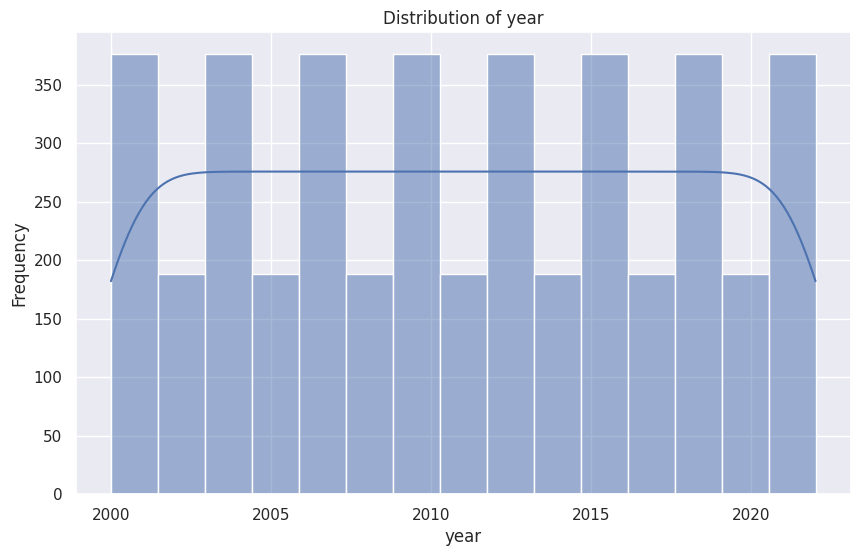

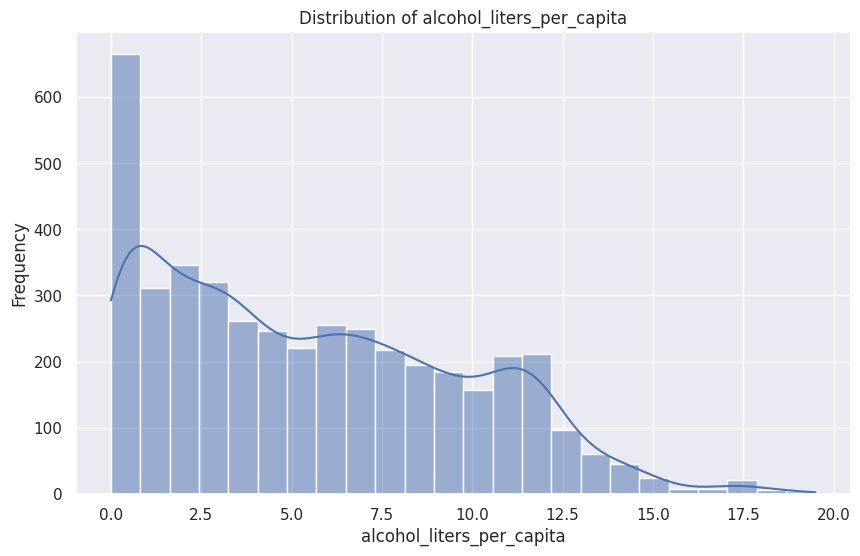

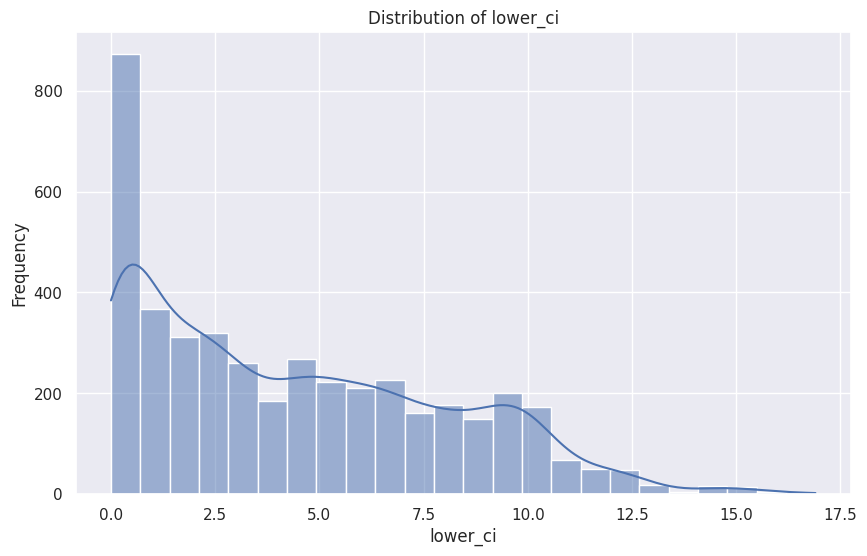

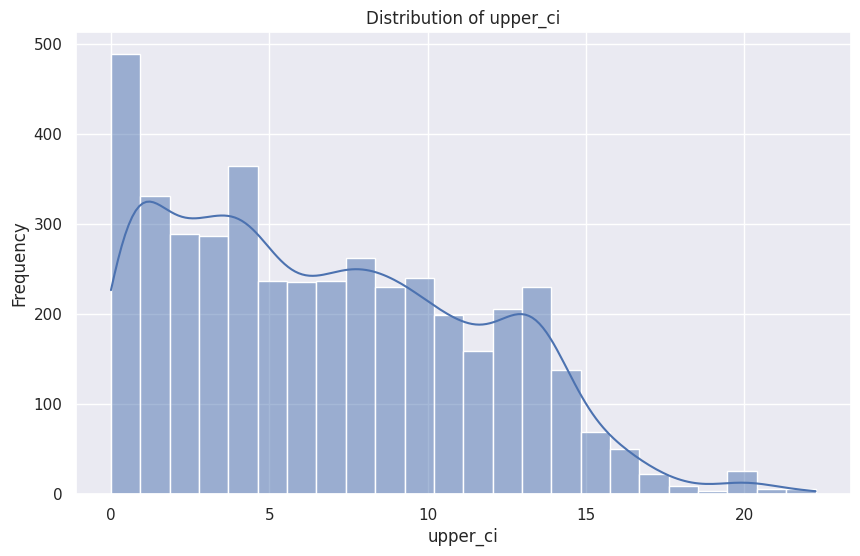

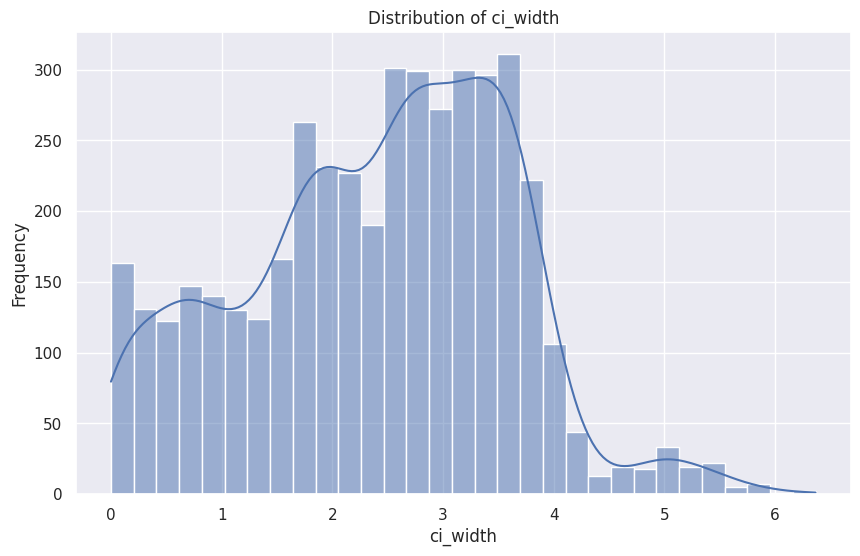

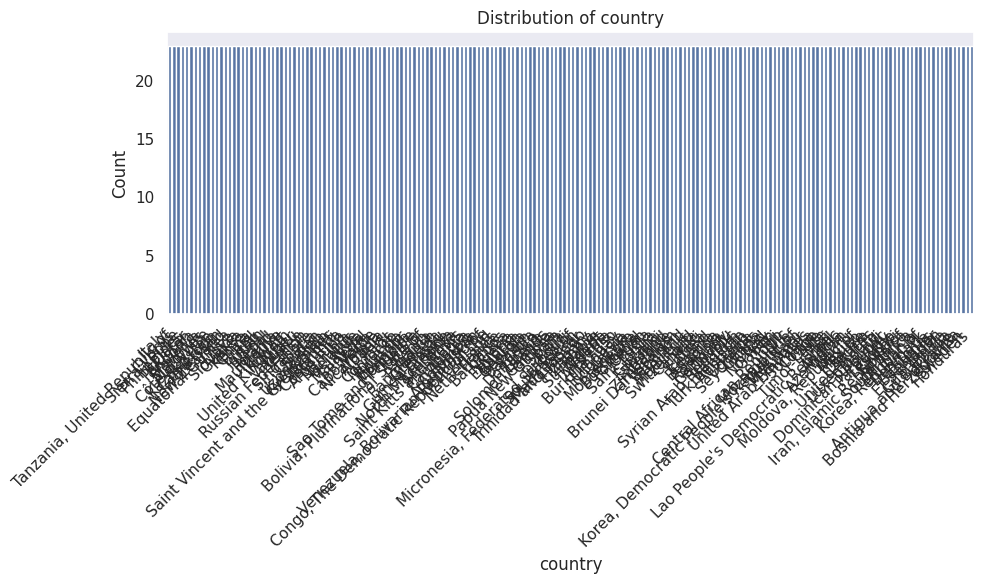

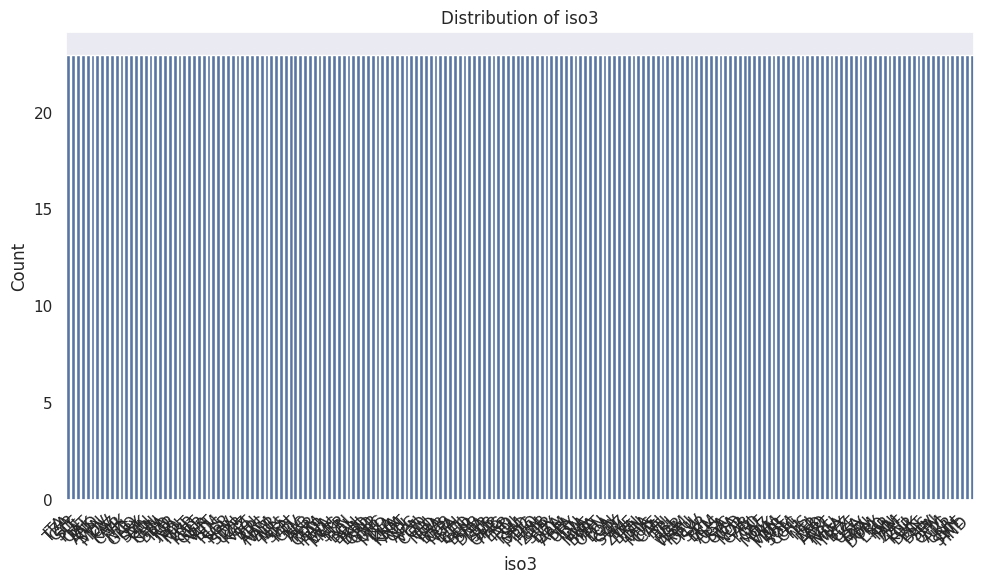

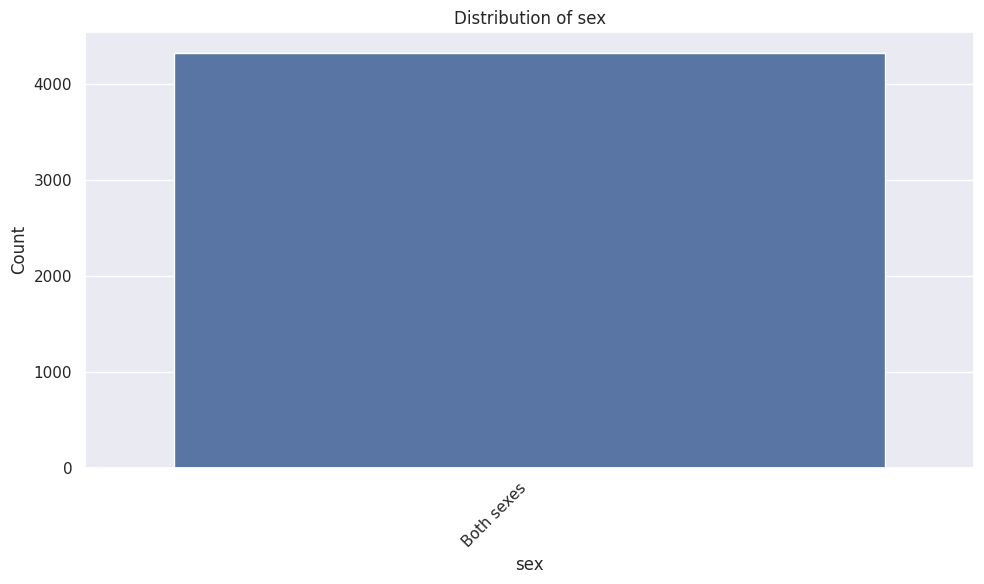

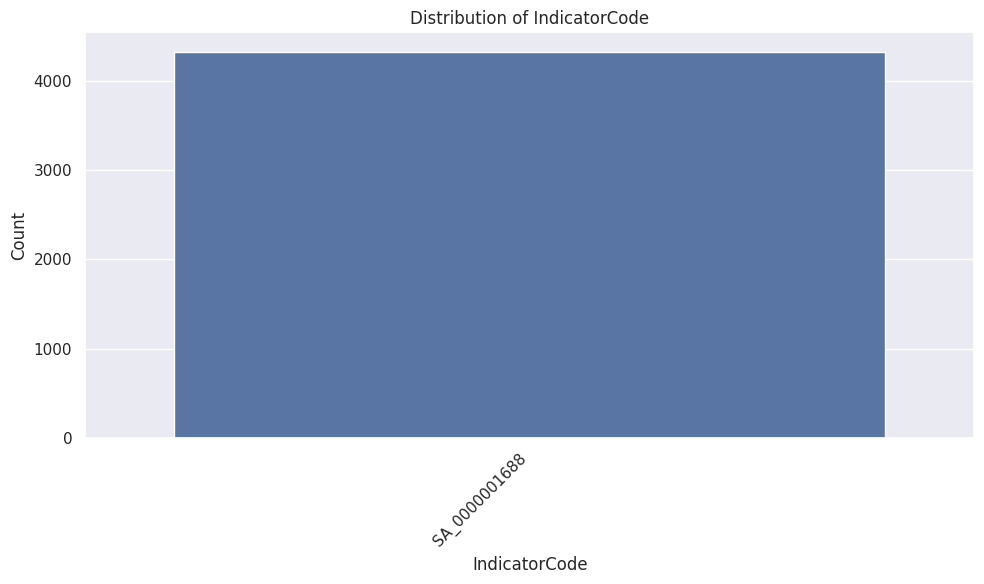

Value counts for country:
country
Italy                           23
Tanzania, United Republic of    23
Cyprus                          23
Sierra Leone                    23
Philippines                     23
                                ..
Antigua and Barbuda             23
Ukraine                         23
Bosnia and Herzegovina          23
Sweden                          23
Honduras                        23
Name: count, Length: 188, dtype: int64

Value counts for iso3:
iso3
ITA    23
TZA    23
CYP    23
SLE    23
PHL    23
       ..
ATG    23
UKR    23
BIH    23
SWE    23
HND    23
Name: count, Length: 188, dtype: int64

Value counts for sex:
sex
Both sexes    4324
Name: count, dtype: int64

Value counts for IndicatorCode:
IndicatorCode
SA_0000001688    4324
Name: count, dtype: int64



In [43]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

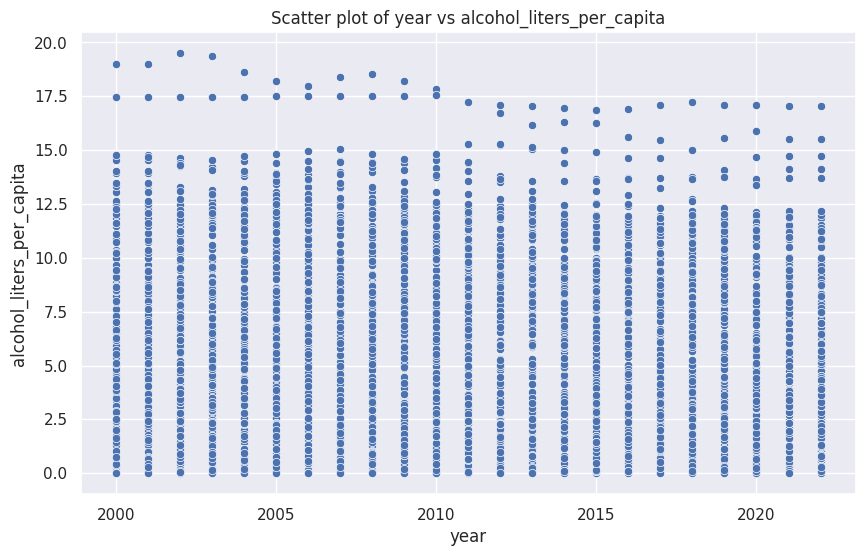

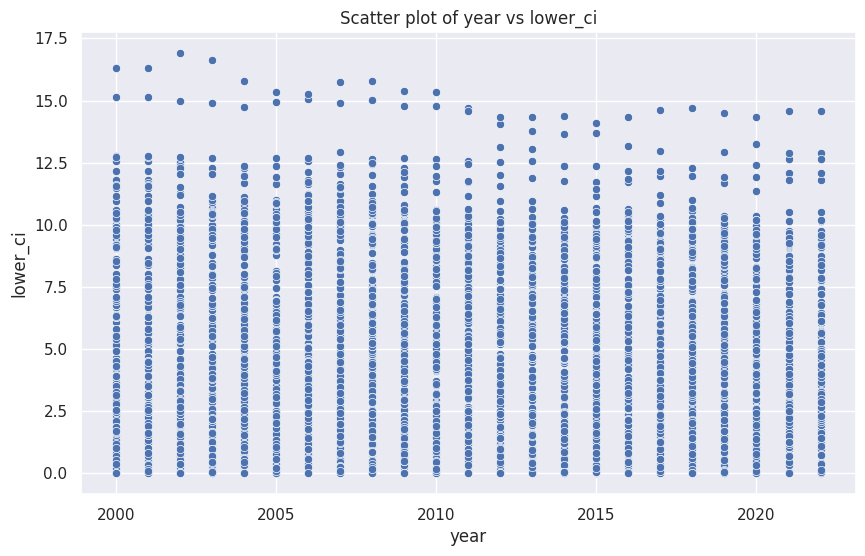

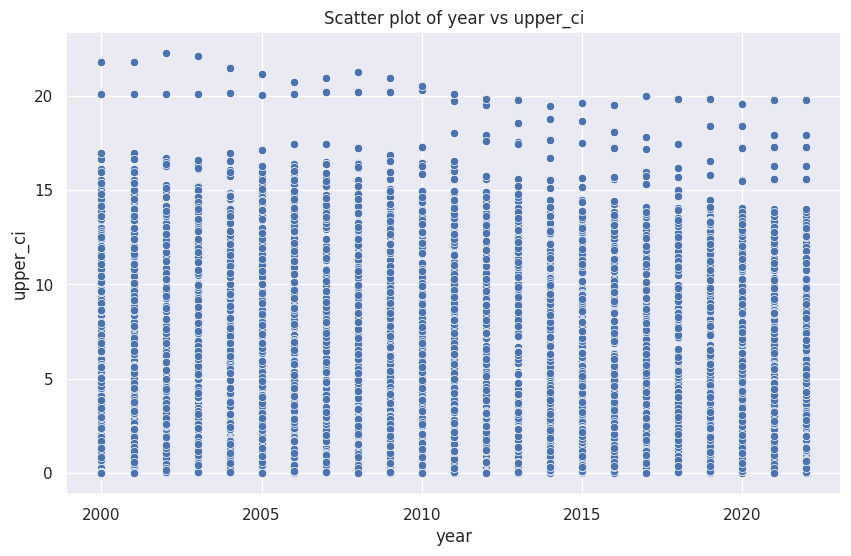

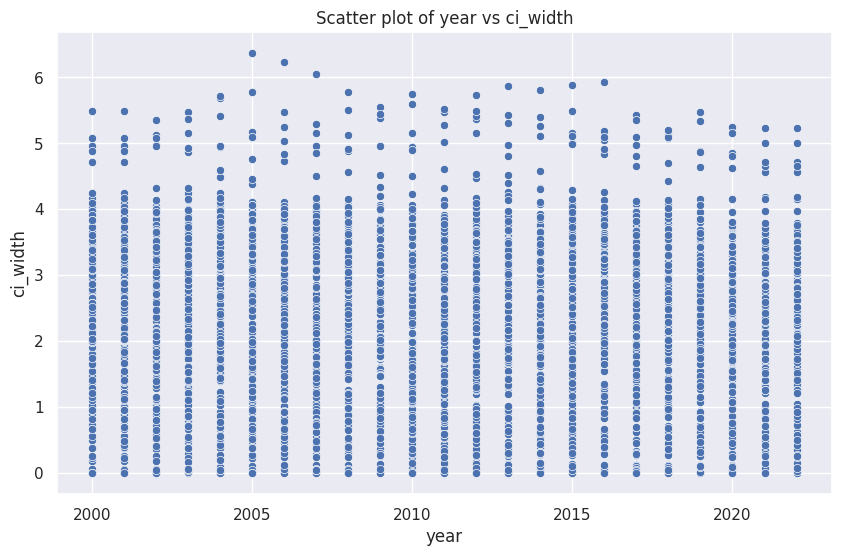

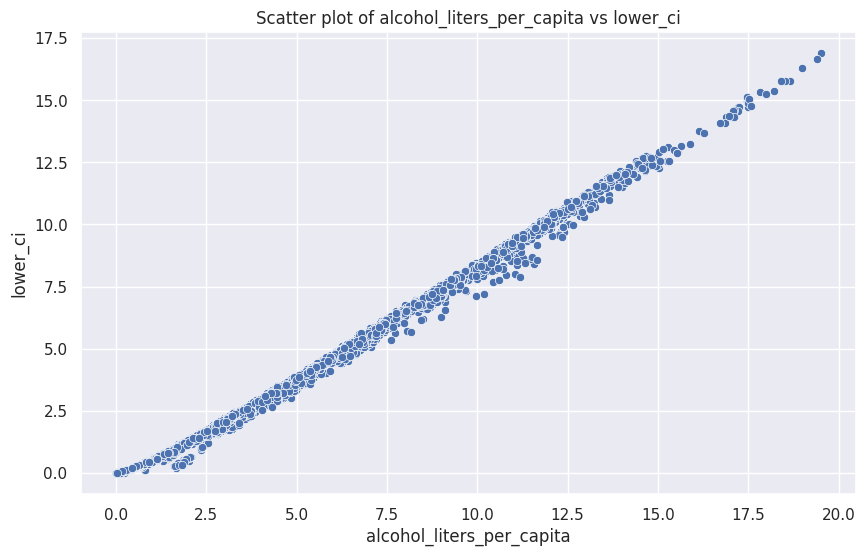

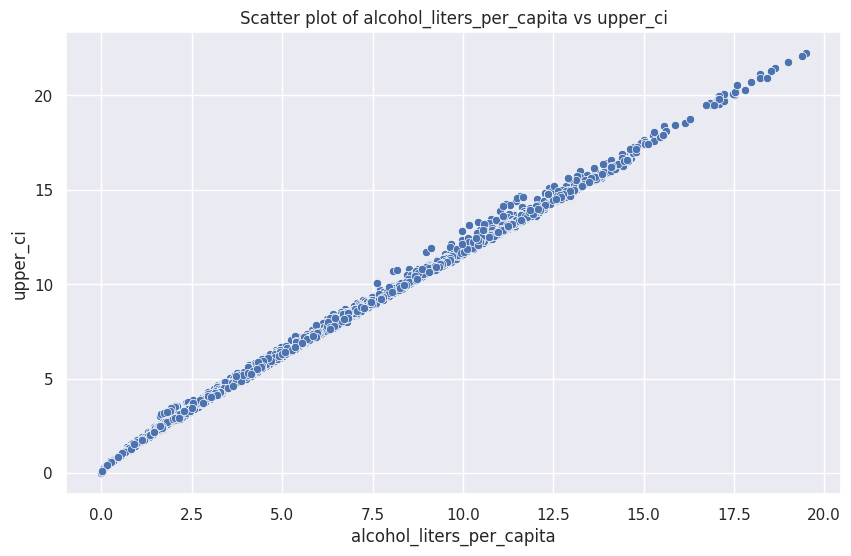

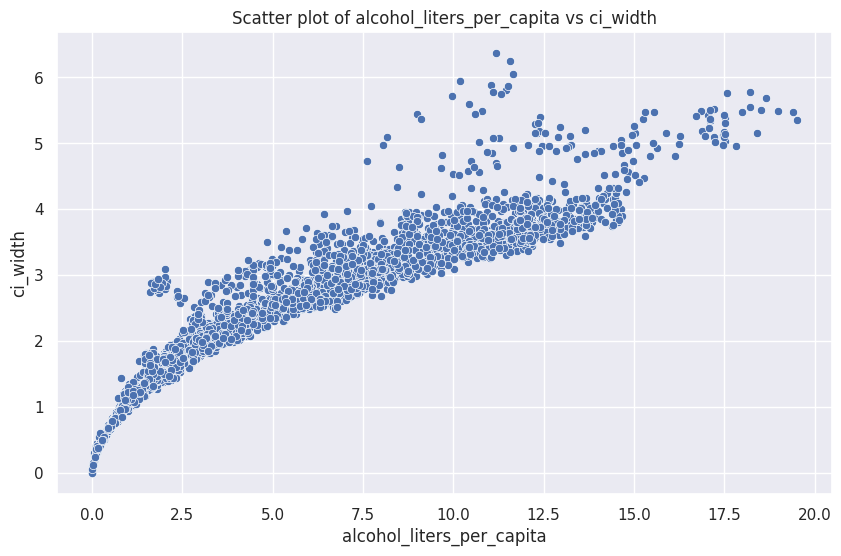

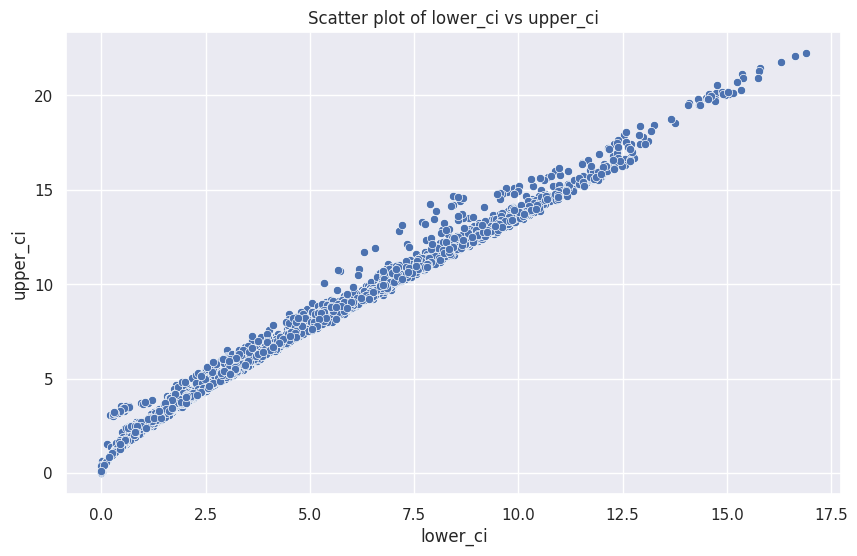

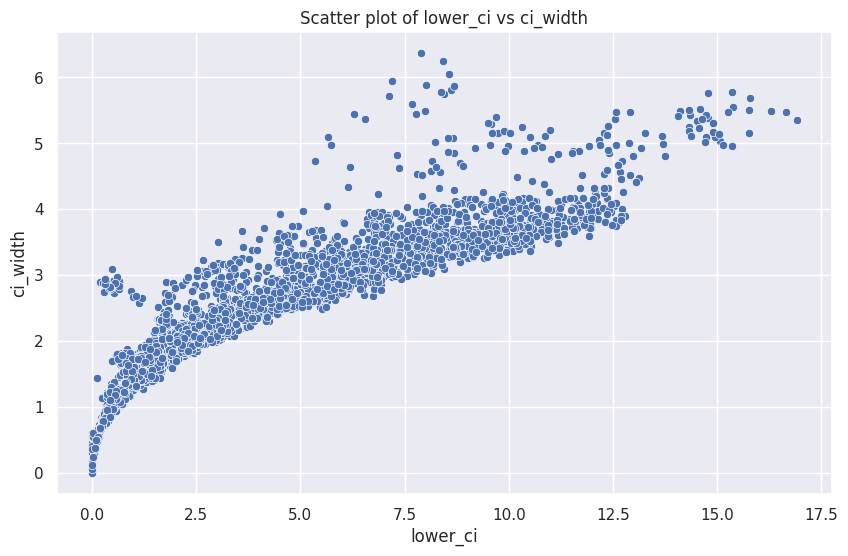

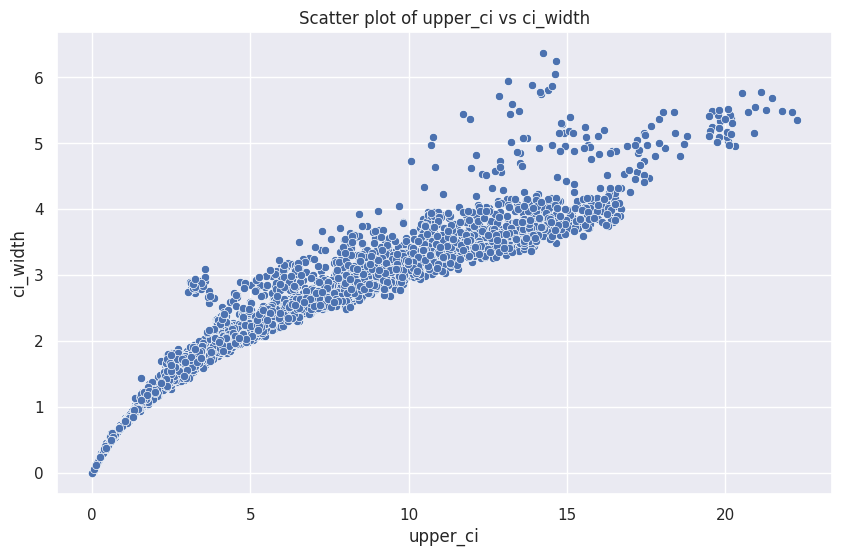

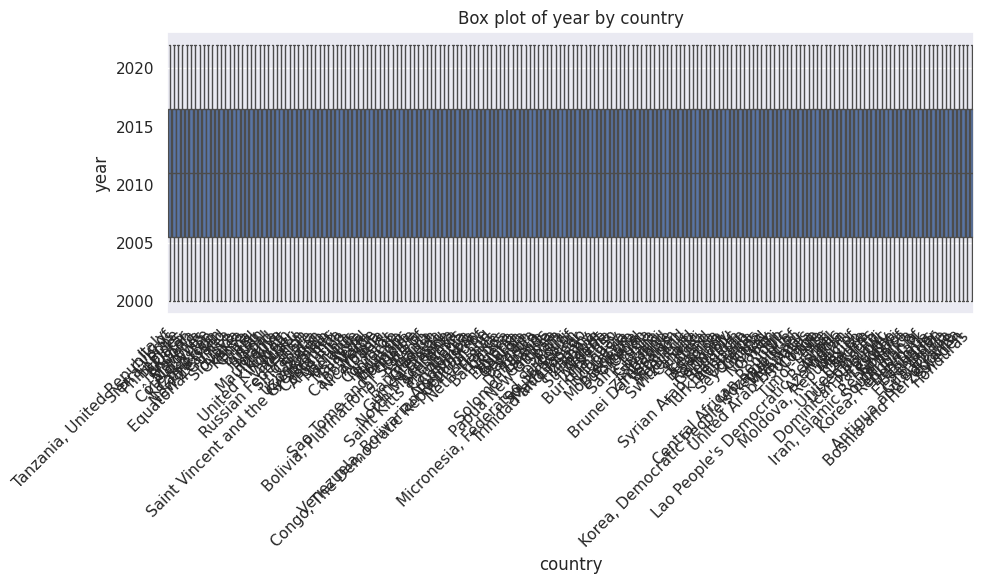

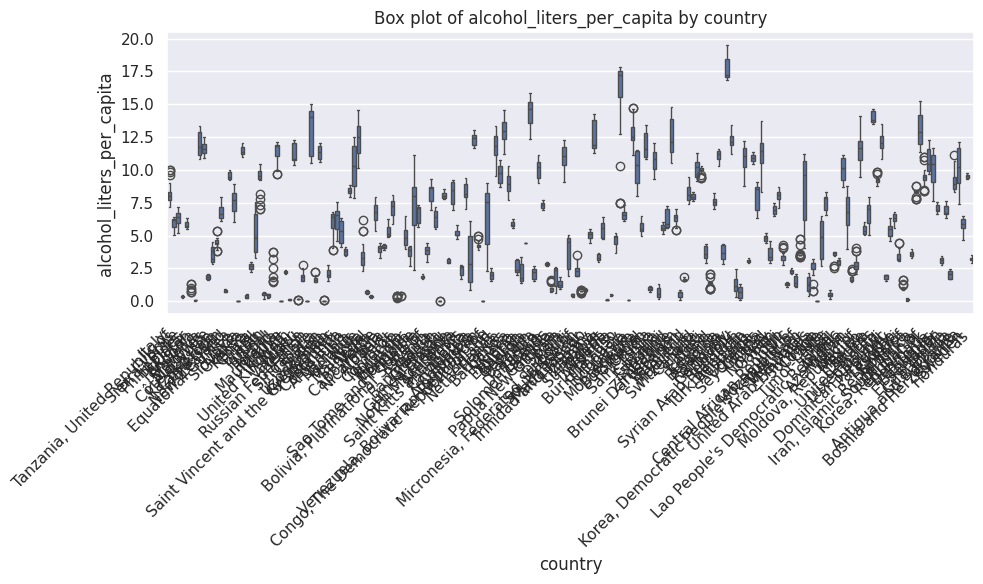

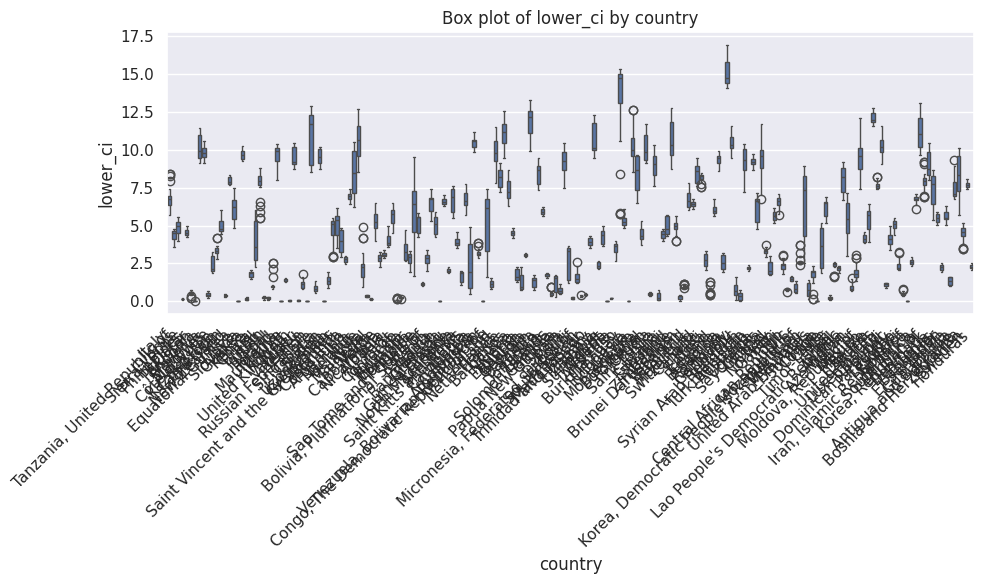

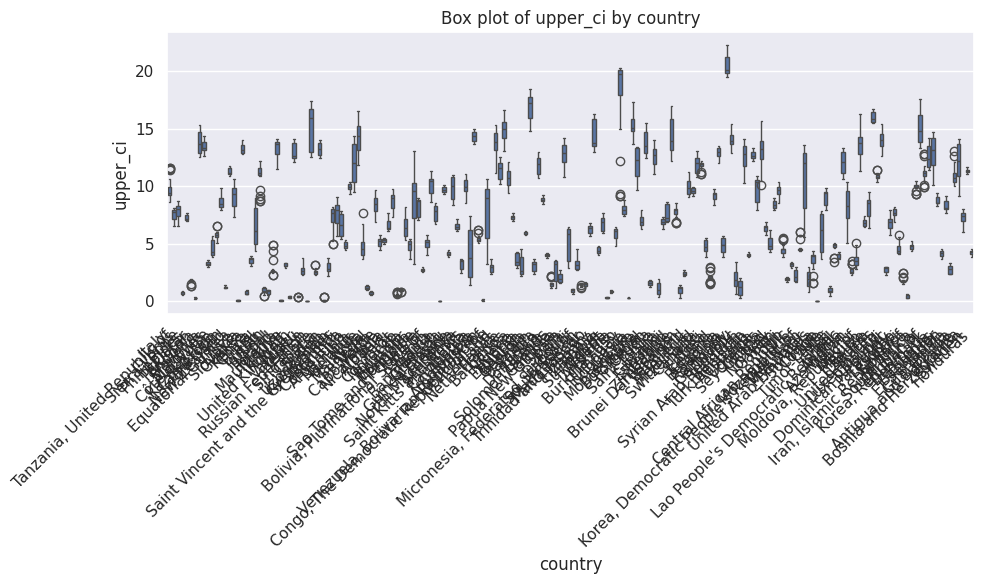

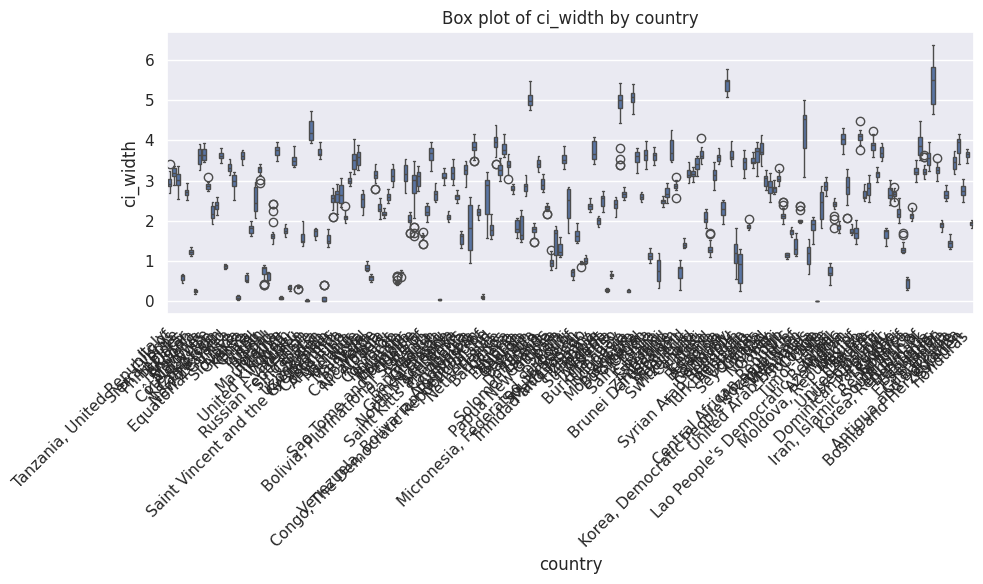

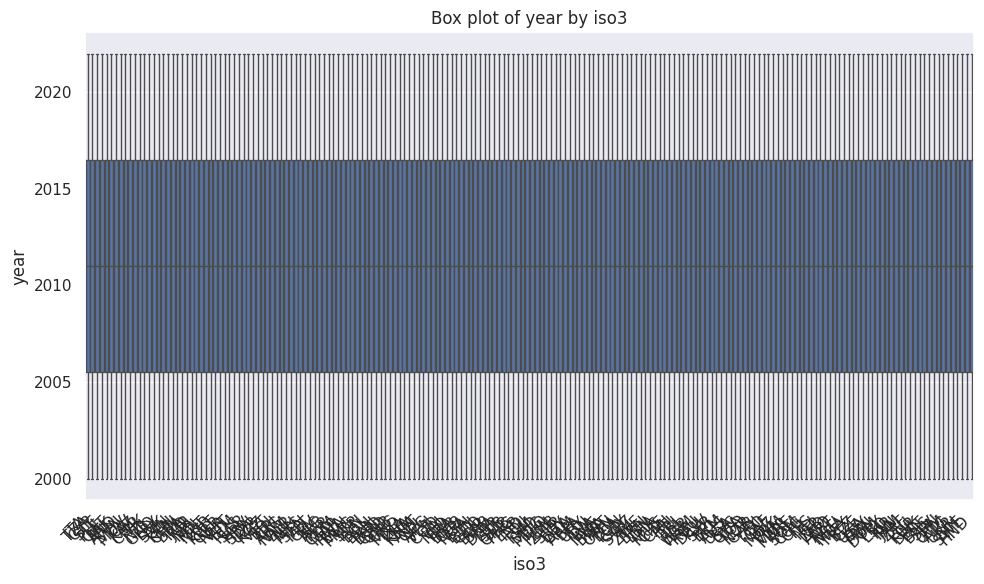

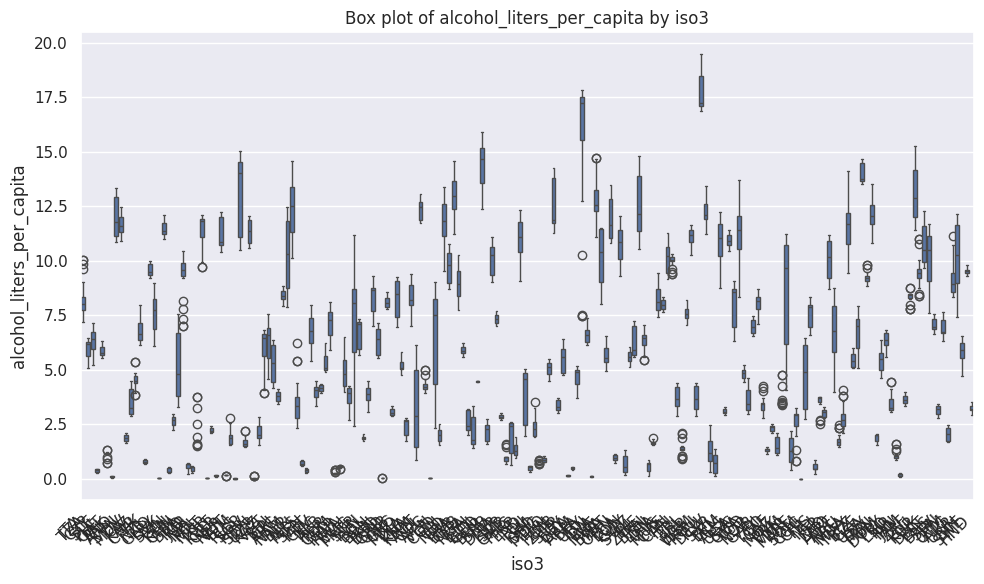

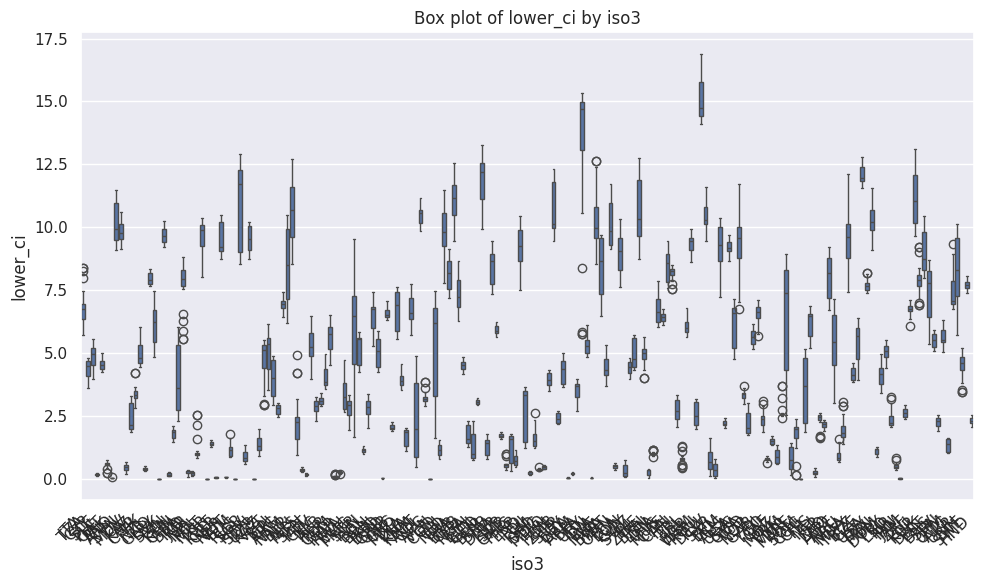

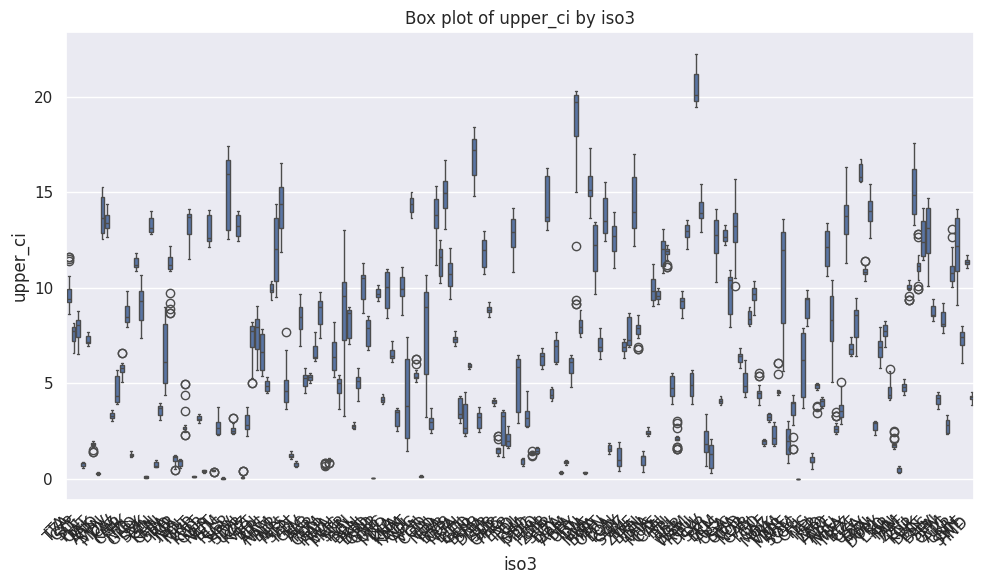

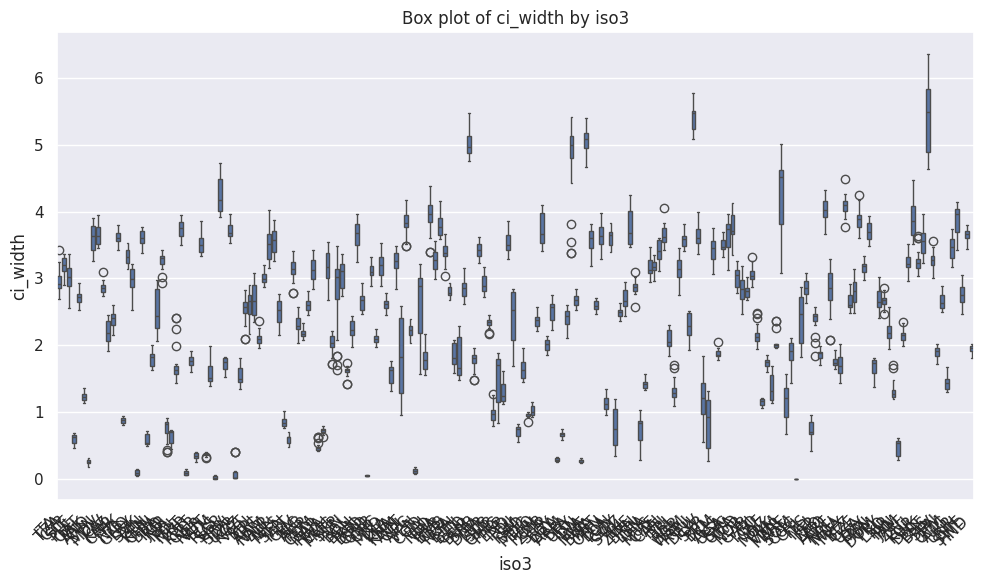

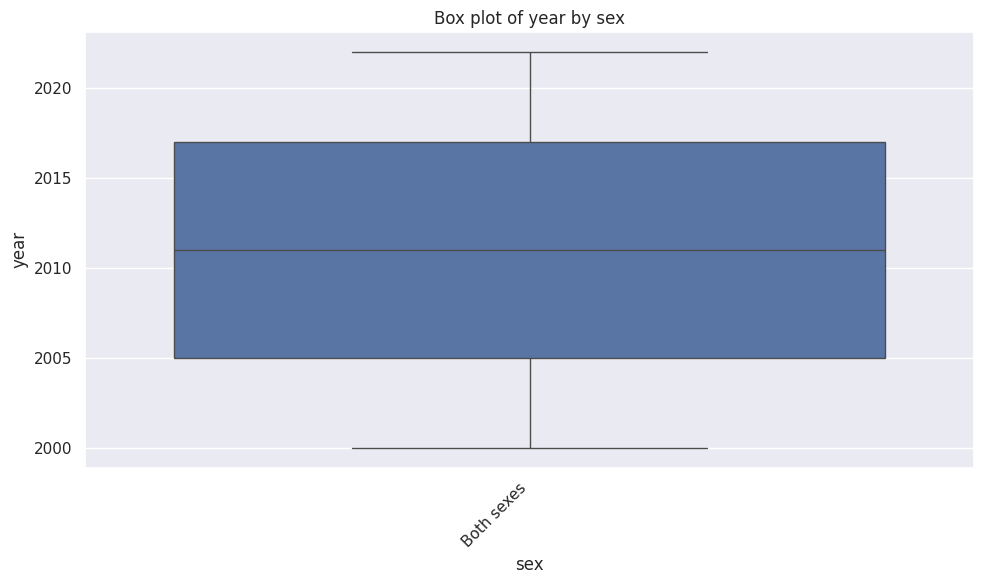

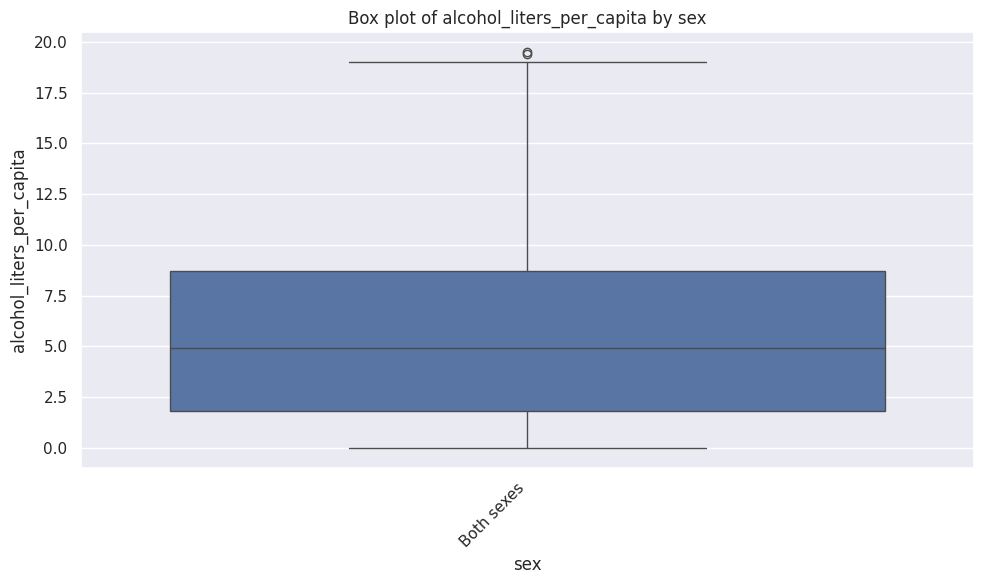

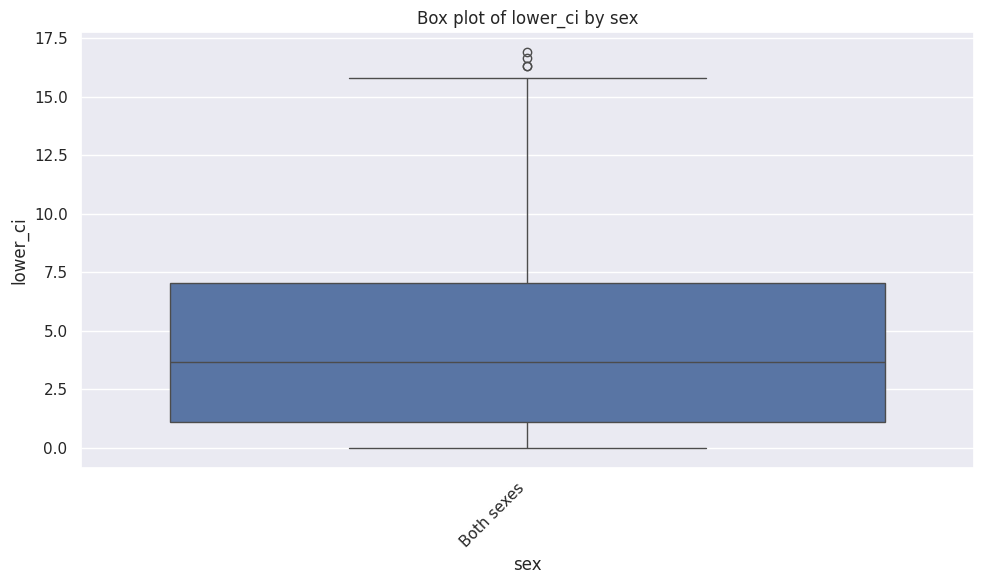

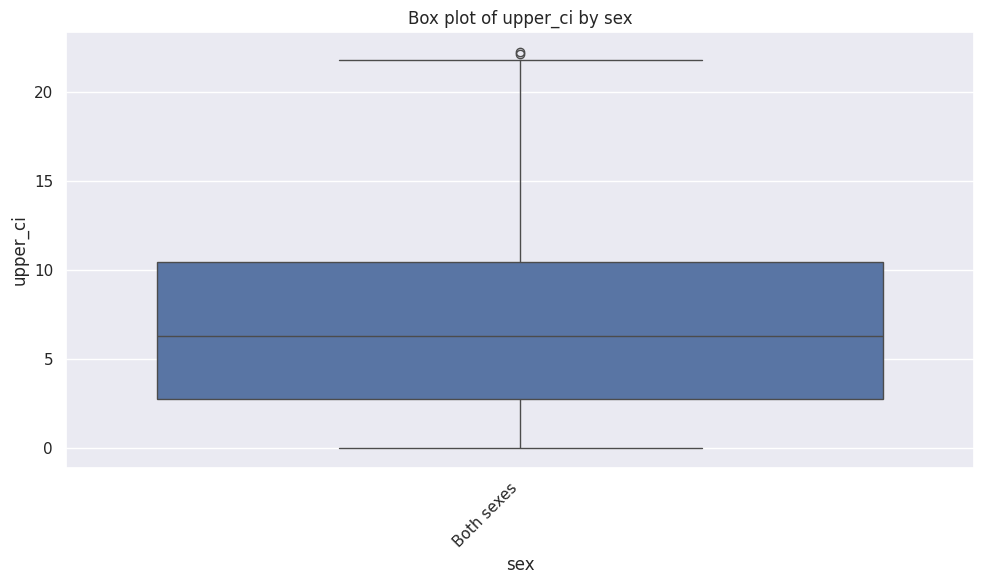

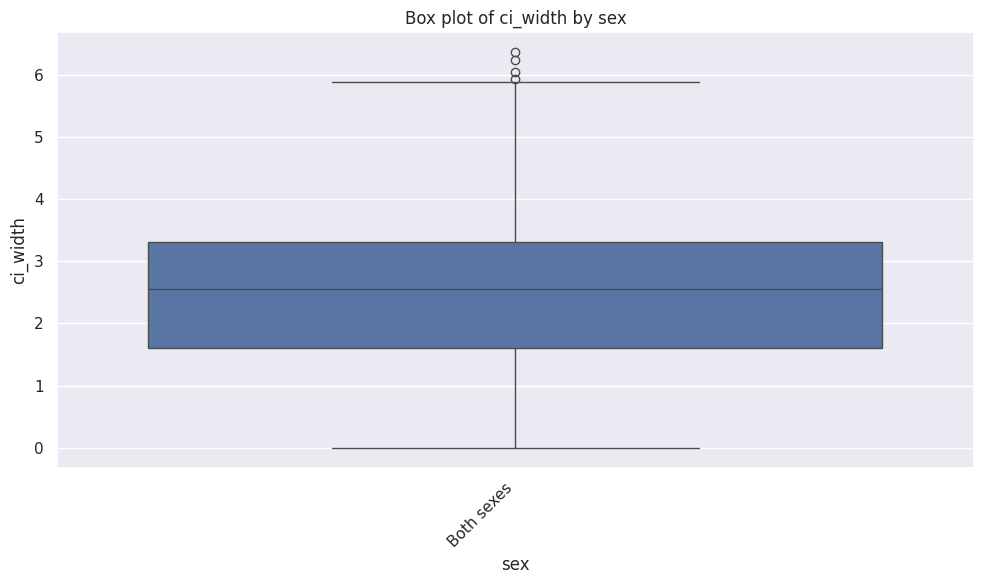

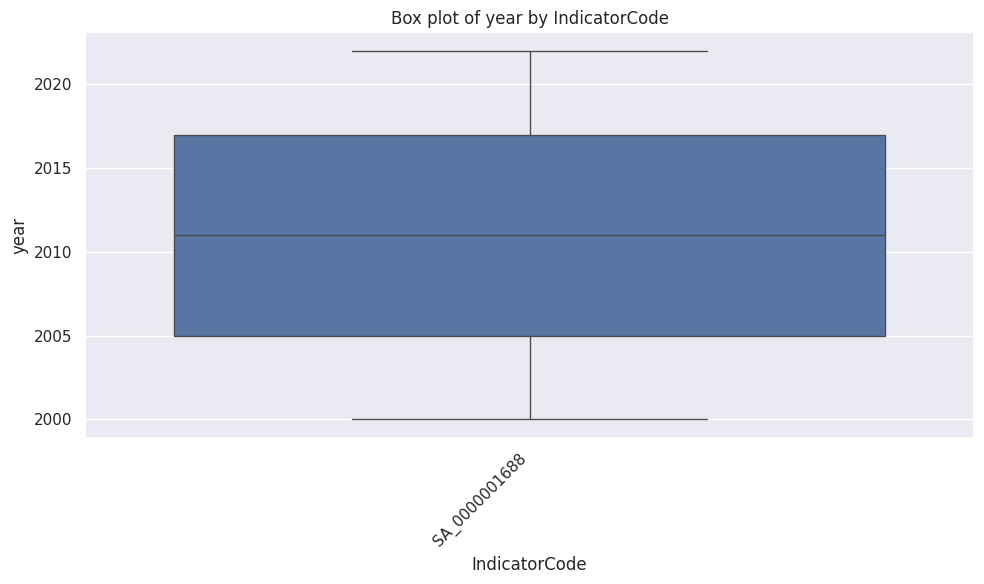

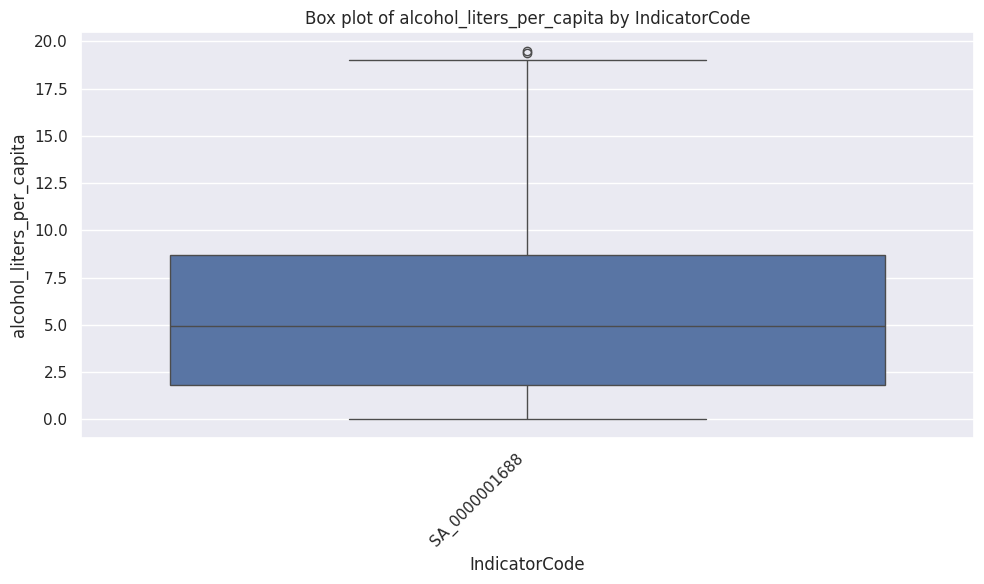

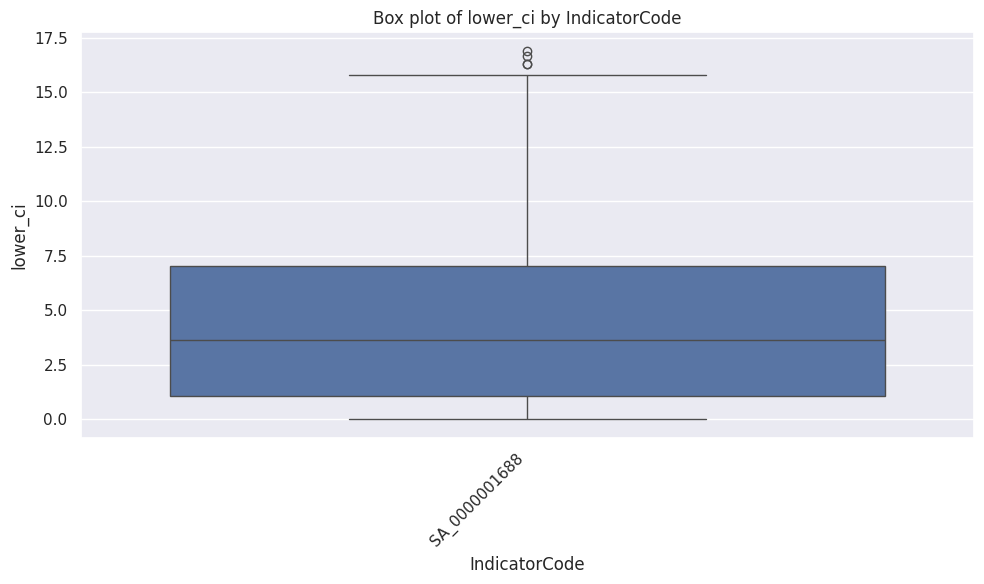

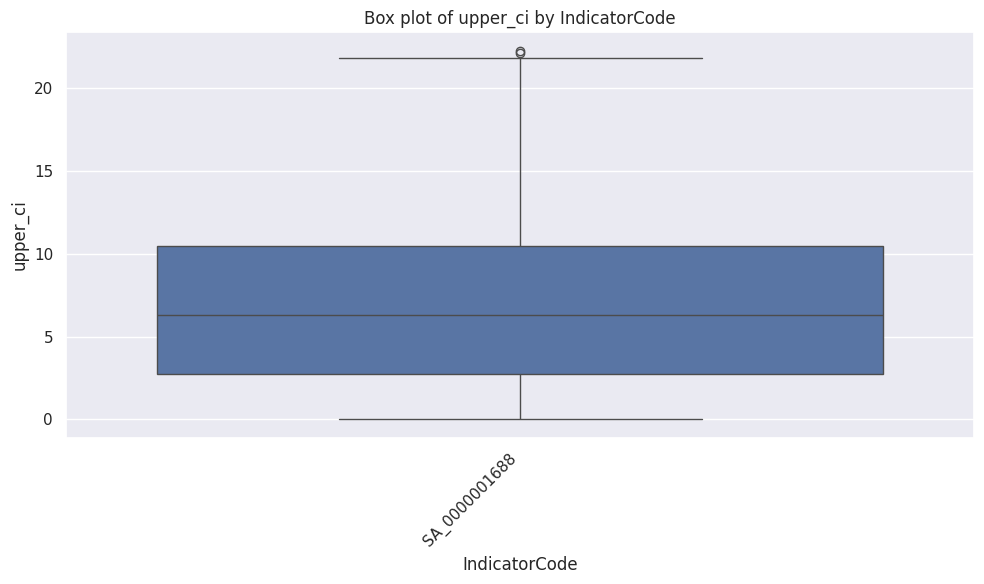

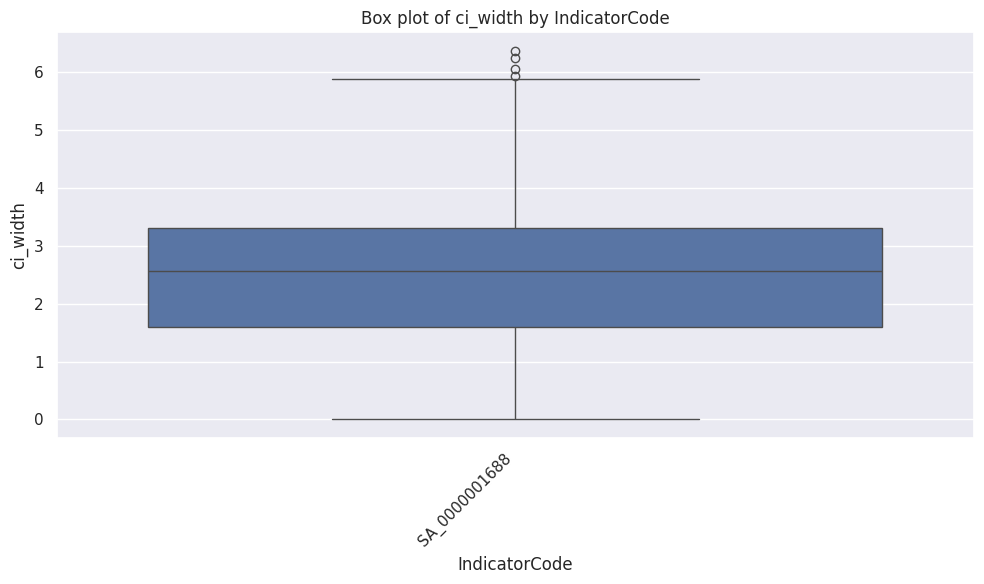

In [44]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

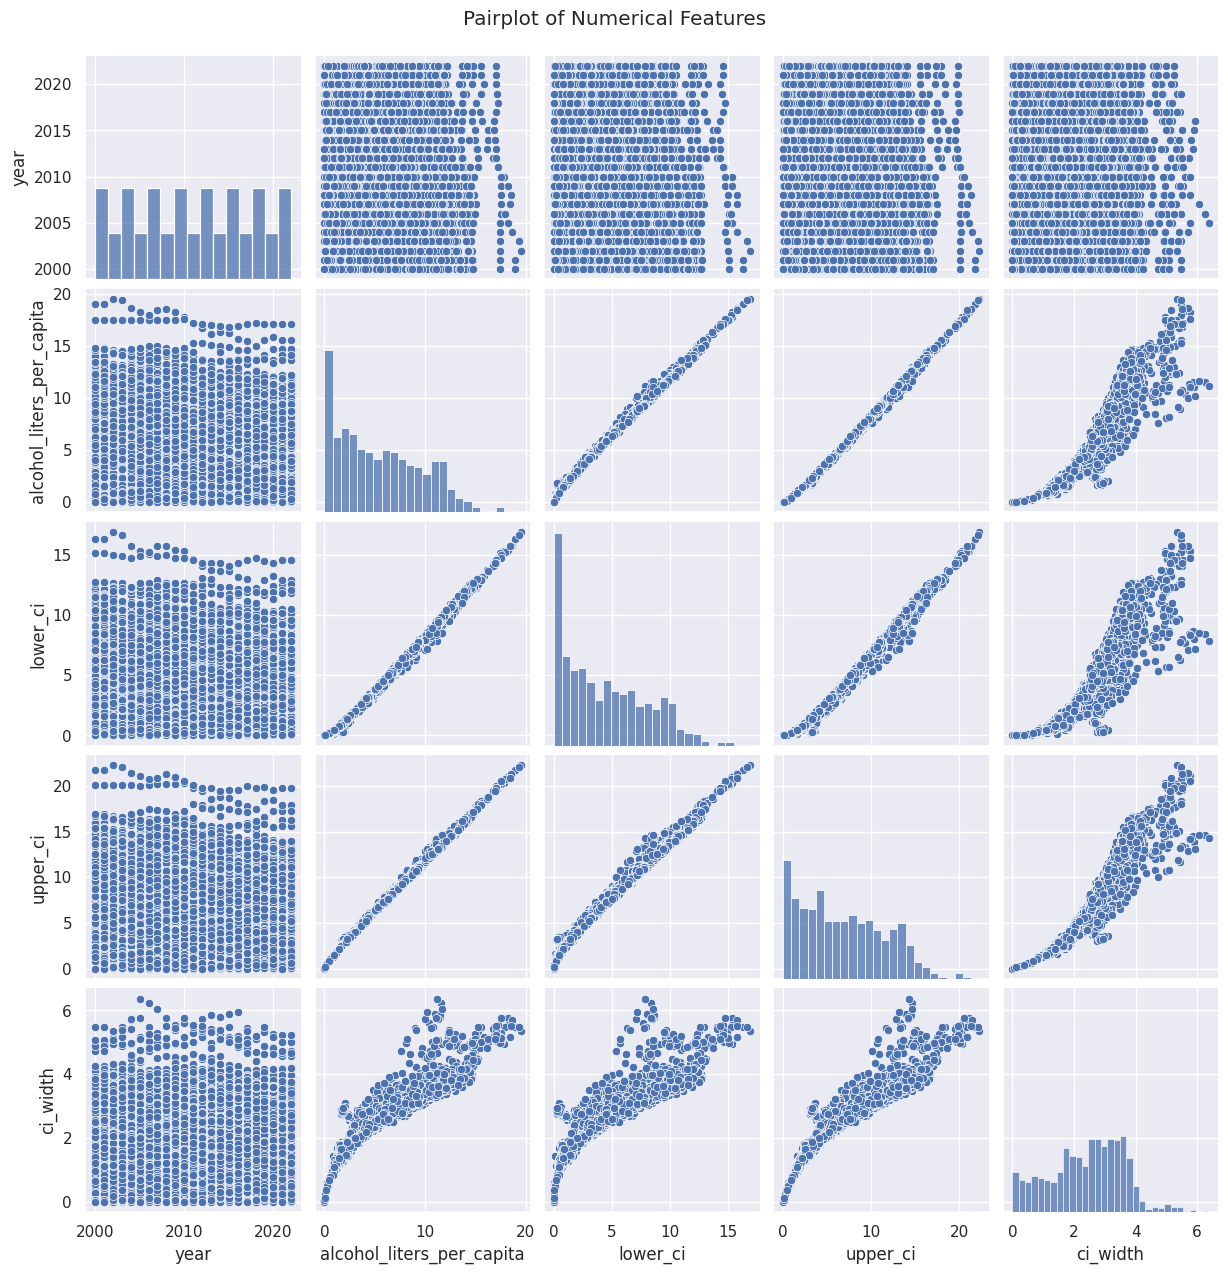

In [45]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

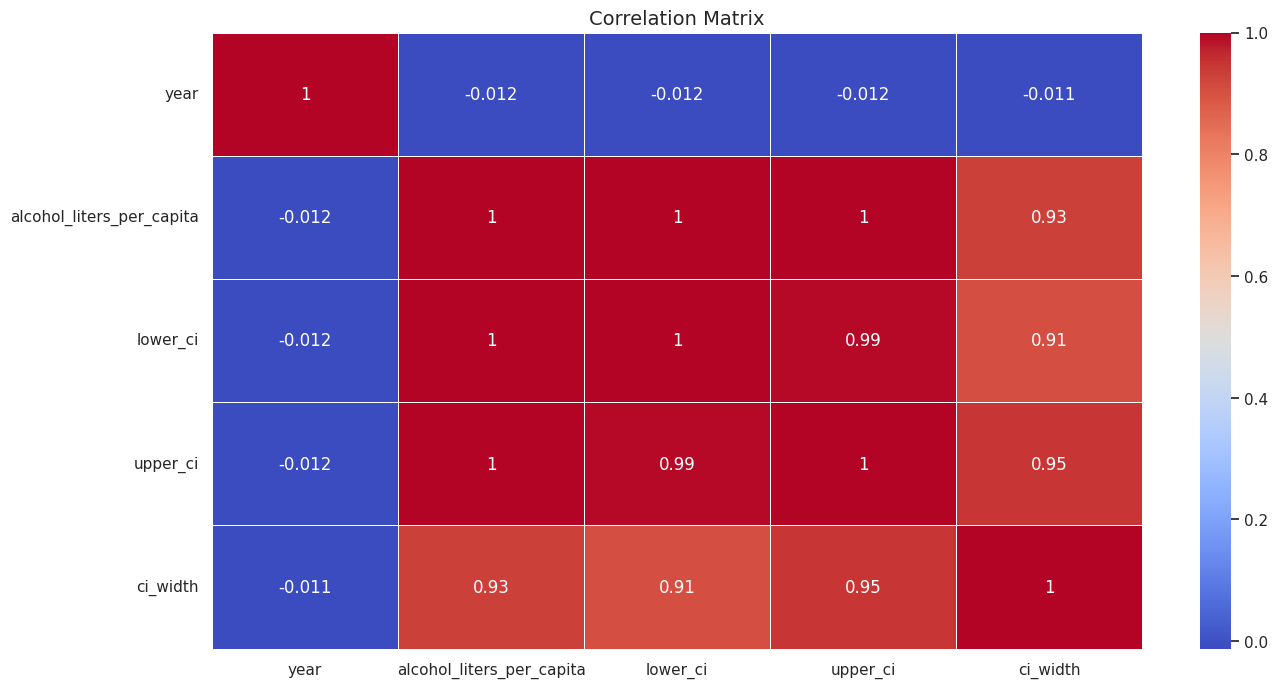

In [46]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You